# Do Upside HDX predictions differ for lambda repressor vs D14A?

This notebook answers the focused question: **do the Upside-derived HDX predictions differ significantly between `lambda_repressor` and `lambda_d14a`?**

Short answer from the local trajectories: **yes.** Using the Upside H-bond output as an HDX protection proxy, D14A has significantly lower predicted protection, hence higher predicted exchange, than lambda repressor across the shared 16-replica reduced-temperature ladder.

Important scope note: this repository does not bundle the full calibrated Upside HDX implementation, residue-level experimental HDX tables, or curated lambda native PDB references. The analysis below is therefore a direct, reproducible **Upside H-bond-protection HDX proxy**, not a fully calibrated experimental HDX fit.

## Prediction model used here

The Upside `.up` files include an `output/hbond` array and residue metadata for backbone donor sites. Following the HDX logic described in the project notes, an amide is treated as protected when its donor H-bond score is above a threshold. For each donor residue, replica, and system:

- `P_protected = fraction(hbond_score > threshold)`
- `P_open = 1 - P_protected`
- `log_protection = -log(P_open)`

Higher `log_protection` means slower predicted exchange. Lower `log_protection` means faster predicted exchange. The default threshold is `0.5`, and a sensitivity check repeats the global test at `0.25`, `0.5`, and `0.75`.

In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')

REPO = Path.cwd()
if not (REPO / 'simulations').exists():
    REPO = REPO.parent
SIM_ROOT = REPO / 'simulations'
FIG_ROOT = REPO / 'docs' / 'figures'
FIG_ROOT.mkdir(parents=True, exist_ok=True)

WT = 'lambda_repressor'
MUT = 'lambda_d14a'
SYSTEMS = [WT, MUT]
DEFAULT_THRESHOLD = 0.5
STRIDE = 10
EPS = 1e-4

AA3_TO_AA1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
}

mpl.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 11,
    'legend.fontsize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.0,
})

print(f'Repo: {REPO}')
print(f'Figures: {FIG_ROOT}')

Repo: \\wsl.localhost\Ubuntu\home\okleinmann\projects\hdx-benchmark-desmond-upside
Figures: \\wsl.localhost\Ubuntu\home\okleinmann\projects\hdx-benchmark-desmond-upside\docs\figures


In [2]:
def valid_up_file(path: Path) -> bool:
    return path.name.endswith('.up') and 'Zone.Identifier' not in path.name and path.stat().st_size > 1024


def run_index(path: Path) -> int:
    match = re.search(r'run\.(\d+)\.up$', path.name)
    if not match:
        return 10_000
    return int(match.group(1))


def run_files(system: str) -> list[Path]:
    remd = SIM_ROOT / system / 'outputs' / 'remd'
    return sorted([p for p in remd.glob(f'{system}.run.*.up') if valid_up_file(p)], key=run_index)


def output_groups(handle: h5py.File):
    index = 0
    while f'output_previous_{index}' in handle:
        yield handle[f'output_previous_{index}']
        index += 1
    if 'output' in handle:
        yield handle['output']


def read_series(path: Path, dataset: str, stride: int = STRIDE) -> np.ndarray:
    arrays = []
    with h5py.File(path, 'r') as handle:
        for group_index, group in enumerate(output_groups(handle)):
            raw = np.asarray(group[dataset])
            start = 0 if group_index == 0 else 1
            arrays.append(raw[start::stride])
    return np.concatenate(arrays, axis=0) if arrays else np.array([])


def read_metadata(system: str) -> tuple[np.ndarray, str]:
    path = run_files(system)[0]
    with h5py.File(path, 'r') as handle:
        donor_resids = np.asarray(handle['input/potential/hbond_energy/donor_resid']).astype(int)
        seq3 = [item.decode() for item in handle['input/sequence'][:]]
    sequence = ''.join(AA3_TO_AA1.get(res, res[0]) for res in seq3)
    return donor_resids, sequence


def bh_fdr(p_values: np.ndarray) -> np.ndarray:
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]
    m = len(p_values)
    adjusted_ranked = np.minimum.accumulate((ranked * m / np.arange(1, m + 1))[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted

inventory = pd.DataFrame({
    'system': SYSTEMS,
    'run_files': [len(run_files(system)) for system in SYSTEMS],
    'first_run': [run_files(system)[0].name for system in SYSTEMS],
    'last_run': [run_files(system)[-1].name for system in SYSTEMS],
})
inventory

,system,run_files,first_run,last_run
0,lambda_repressor,16,lambda_repressor.run.0.up,lambda_repressor.run.15.up
1,lambda_d14a,16,lambda_d14a.run.0.up,lambda_d14a.run.15.up


In [3]:
wt_donors, wt_sequence = read_metadata(WT)
mut_donors, mut_sequence = read_metadata(MUT)

sequence_diffs = []
for position, (wt_res, mut_res) in enumerate(zip(wt_sequence, mut_sequence), start=1):
    if wt_res != mut_res:
        sequence_diffs.append({'sequence_position_1_based': position, WT: wt_res, MUT: mut_res})

metadata = pd.DataFrame({
    'system': SYSTEMS,
    'n_residues': [len(wt_sequence), len(mut_sequence)],
    'n_backbone_donor_sites_scored': [len(wt_donors), len(mut_donors)],
    'sequence': [wt_sequence, mut_sequence],
})

display(metadata)
display(pd.DataFrame(sequence_diffs))

assert np.array_equal(wt_donors, mut_donors), 'Donor residue definitions differ; paired residue tests are not valid.'

,system,n_residues,n_backbone_donor_sites_scored,sequence
0,lambda_repressor,87,85,PLTQEQLEDARRLKAIYEKKKNELGLSQESVADKMGMGQSGVGALF...
1,lambda_d14a,87,85,PLTQEQLEAARRLKAIYEKKKNELGLSQESVADKMGMGQSGVGALF...


,sequence_position_1_based,lambda_repressor,lambda_d14a
0,9,D,A


In [4]:
def hdx_proxy_profile(system: str, threshold: float = DEFAULT_THRESHOLD, stride: int = STRIDE) -> pd.DataFrame:
    donor_resids, sequence = read_metadata(system)
    rows = []
    for path in run_files(system):
        replica = run_index(path)
        hbond = read_series(path, 'hbond', stride=stride)[:, :len(donor_resids)]
        temperature = read_series(path, 'temperature', stride=stride).reshape(-1)
        protected = hbond > threshold
        p_protected = protected.mean(axis=0)
        p_open = 1.0 - p_protected
        log_protection = -np.log(np.clip(p_open, EPS, 1.0))
        for site_index, donor_resid in enumerate(donor_resids):
            rows.append({
                'system': system,
                'replica': replica,
                'temperature': float(np.nanmedian(temperature)),
                'residue_index_0_based': int(donor_resid),
                'residue_position_1_based': int(donor_resid) + 1,
                'residue': sequence[int(donor_resid)],
                'p_protected': float(p_protected[site_index]),
                'p_open': float(p_open[site_index]),
                'log_protection': float(log_protection[site_index]),
                'n_frames': int(hbond.shape[0]),
                'threshold': threshold,
            })
    return pd.DataFrame(rows)

profiles = pd.concat([hdx_proxy_profile(system) for system in SYSTEMS], ignore_index=True)
profiles.head()

,system,replica,temperature,residue_index_0_based,residue_position_1_based,residue,p_protected,p_open,log_protection,n_frames,threshold
0,lambda_repressor,0,0.8,1,2,L,0.046875,0.953125,0.048009,192,0.5
1,lambda_repressor,0,0.8,2,3,T,0.000000,1.000000,-0.000000,192,0.5
2,lambda_repressor,0,0.8,3,4,Q,0.000000,1.000000,-0.000000,192,0.5
3,lambda_repressor,0,0.8,4,5,E,0.000000,1.000000,-0.000000,192,0.5
4,lambda_repressor,0,0.8,5,6,Q,0.005208,0.994792,0.005222,192,0.5


In [5]:
global_by_replica = (
    profiles.groupby(['system', 'replica', 'temperature'], as_index=False)
    .agg(mean_log_protection=('log_protection', 'mean'), mean_p_open=('p_open', 'mean'), mean_p_protected=('p_protected', 'mean'))
)
wide_global = global_by_replica.pivot(index='replica', columns='system', values='mean_log_protection')
wide_open = global_by_replica.pivot(index='replica', columns='system', values='mean_p_open')

delta_global = wide_global[MUT] - wide_global[WT]
delta_open = wide_open[MUT] - wide_open[WT]

test_t = stats.ttest_rel(wide_global[MUT], wide_global[WT])
test_w = stats.wilcoxon(wide_global[MUT], wide_global[WT])
open_t = stats.ttest_rel(wide_open[MUT], wide_open[WT])

summary_global = pd.DataFrame({
    'quantity': ['mean_log_protection', 'mean_p_open'],
    WT: [wide_global[WT].mean(), wide_open[WT].mean()],
    MUT: [wide_global[MUT].mean(), wide_open[MUT].mean()],
    'mut_minus_wt': [delta_global.mean(), delta_open.mean()],
    'paired_t_p': [test_t.pvalue, open_t.pvalue],
    'wilcoxon_p_log_protection_only': [test_w.pvalue, np.nan],
})
summary_global

,quantity,lambda_repressor,lambda_d14a,mut_minus_wt,paired_t_p,wilcoxon_p_log_protection_only
0,mean_log_protection,1.076129,0.959906,-0.116223,0.000033,0.000214
1,mean_p_open,0.574391,0.603669,0.029278,0.000013,NaN


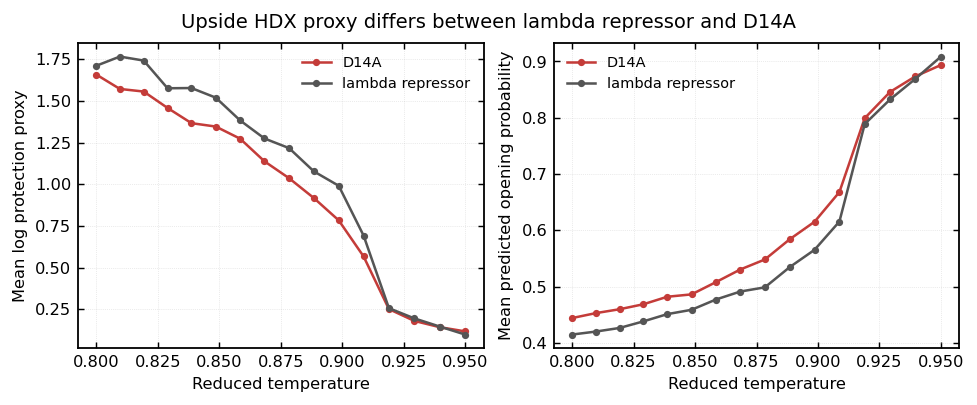

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), constrained_layout=True)
colors = {WT: '#555555', MUT: '#c43c39'}
labels = {WT: 'lambda repressor', MUT: 'D14A'}

for system, group in global_by_replica.groupby('system'):
    group = group.sort_values('temperature')
    axes[0].plot(group['temperature'], group['mean_log_protection'], marker='o', ms=3, lw=1.4, color=colors[system], label=labels[system])
    axes[1].plot(group['temperature'], group['mean_p_open'], marker='o', ms=3, lw=1.4, color=colors[system], label=labels[system])

axes[0].set_ylabel('Mean log protection proxy')
axes[1].set_ylabel('Mean predicted opening probability')
for ax in axes:
    ax.set_xlabel('Reduced temperature')
    ax.grid(ls=':', lw=0.4, alpha=0.45)
    ax.legend(frameon=False)
fig.suptitle('Upside HDX proxy differs between lambda repressor and D14A')
fig.savefig(FIG_ROOT / 'lambda_repressor_vs_d14a_hdx_proxy_global.png', bbox_inches='tight')
plt.show()

In [7]:
site_rows = []
for residue_position, group in profiles.groupby('residue_position_1_based'):
    wt = group[group['system'] == WT].sort_values('replica')
    mut = group[group['system'] == MUT].sort_values('replica')
    if len(wt) != len(mut):
        continue
    delta = mut['log_protection'].to_numpy() - wt['log_protection'].to_numpy()
    t_result = stats.ttest_rel(mut['log_protection'], wt['log_protection'])
    site_rows.append({
        'residue_position_1_based': int(residue_position),
        'residue': wt['residue'].iloc[0],
        'wt_mean_log_protection': float(wt['log_protection'].mean()),
        'd14a_mean_log_protection': float(mut['log_protection'].mean()),
        'delta_log_protection_d14a_minus_wt': float(delta.mean()),
        'delta_p_open_d14a_minus_wt': float((mut['p_open'].to_numpy() - wt['p_open'].to_numpy()).mean()),
        'paired_t_p': float(t_result.pvalue),
    })

site_stats = pd.DataFrame(site_rows)
site_stats['q_value_bh_fdr'] = bh_fdr(site_stats['paired_t_p'].to_numpy())
site_stats['significant_fdr_0_05'] = site_stats['q_value_bh_fdr'] < 0.05
site_stats['abs_delta'] = site_stats['delta_log_protection_d14a_minus_wt'].abs()

print(f"FDR-significant donor sites at q < 0.05: {site_stats['significant_fdr_0_05'].sum()} / {len(site_stats)}")
site_stats.sort_values('abs_delta', ascending=False).head(15)

FDR-significant donor sites at q < 0.05: 46 / 85


,residue_position_1_based,residue,wt_mean_log_protection,d14a_mean_log_protection,delta_log_protection_d14a_minus_wt,delta_p_open_d14a_minus_wt,paired_t_p,q_value_bh_fdr,significant_fdr_0_05,abs_delta
57,59,L,2.288024,1.467223,-0.820801,0.126922,0.000081,0.000982,True,0.820801
56,58,A,2.274908,1.598210,-0.676698,0.116469,0.000432,0.002447,True,0.676698
55,57,A,2.345060,1.731305,-0.613754,0.105033,0.004080,0.011959,True,0.613754
30,32,A,1.632881,1.111652,-0.521228,0.116776,0.000017,0.000654,True,0.521228
10,12,R,2.380964,2.861512,0.480548,-0.051836,0.000026,0.000654,True,0.480548
8,10,A,3.335010,2.889098,-0.445912,-0.024787,0.249858,0.348163,False,0.445912
59,61,A,3.459842,3.026569,-0.433273,0.032188,0.444386,0.555482,False,0.433273
44,46,F,1.032027,0.599481,-0.432546,0.154578,0.000077,0.000982,True,0.432546
16,18,E,3.408445,2.984808,-0.423636,0.015637,0.366434,0.486670,False,0.423636
31,33,D,1.331495,0.914871,-0.416625,0.114909,0.000035,0.000654,True,0.416625


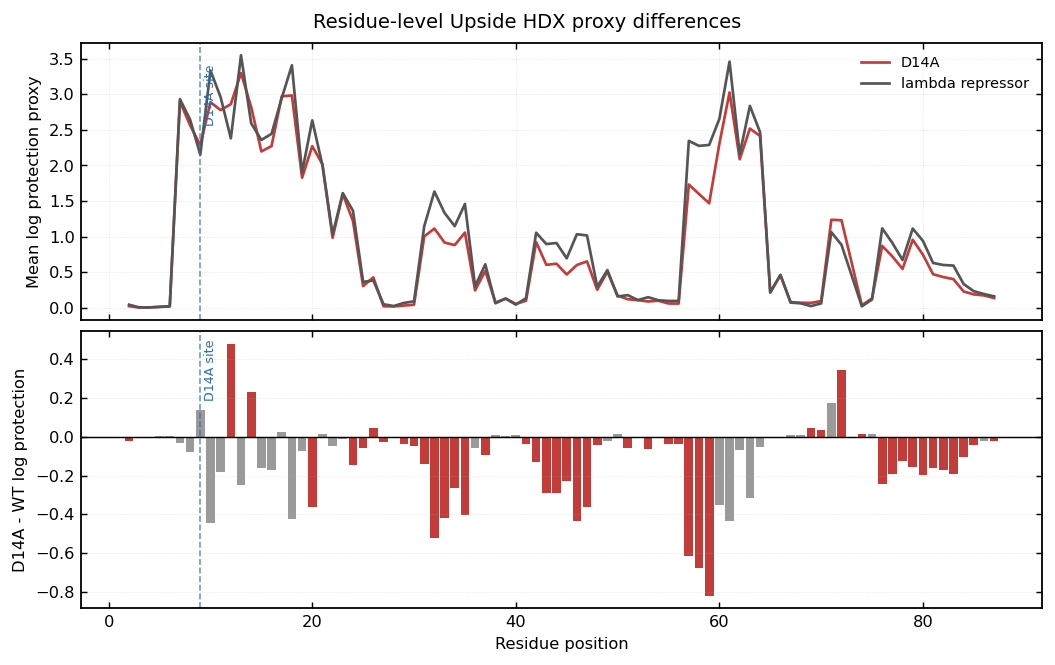

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8.0, 5.0), sharex=True, constrained_layout=True)

for system, group in profiles.groupby('system'):
    site_mean = group.groupby('residue_position_1_based', as_index=False)['log_protection'].mean()
    axes[0].plot(site_mean['residue_position_1_based'], site_mean['log_protection'], color=colors[system], lw=1.5, label=labels[system])

plot_stats = site_stats.sort_values('residue_position_1_based')
bar_colors = np.where(plot_stats['significant_fdr_0_05'], '#c43c39', '#9a9a9a')
axes[1].bar(plot_stats['residue_position_1_based'], plot_stats['delta_log_protection_d14a_minus_wt'], color=bar_colors, width=0.85)
axes[1].axhline(0, color='black', lw=0.8)

for row in sequence_diffs:
    for ax in axes:
        ax.axvline(row['sequence_position_1_based'], color='#2b6cb0', ls='--', lw=0.9, alpha=0.7)
        ax.text(row['sequence_position_1_based'] + 0.4, ax.get_ylim()[1] * 0.92, 'D14A site', color='#2b6cb0', fontsize=7, rotation=90, va='top')

axes[0].set_ylabel('Mean log protection proxy')
axes[0].legend(frameon=False)
axes[0].grid(ls=':', lw=0.4, alpha=0.45)
axes[1].set_ylabel('D14A - WT log protection')
axes[1].set_xlabel('Residue position')
axes[1].grid(axis='y', ls=':', lw=0.4, alpha=0.45)
fig.suptitle('Residue-level Upside HDX proxy differences')
fig.savefig(FIG_ROOT / 'lambda_repressor_vs_d14a_hdx_proxy_residue_deltas.png', bbox_inches='tight')
plt.show()

In [9]:
def global_test_for_threshold(threshold: float) -> dict[str, float]:
    prof = pd.concat([hdx_proxy_profile(system, threshold=threshold) for system in SYSTEMS], ignore_index=True)
    global_rep = prof.groupby(['system', 'replica'], as_index=False).agg(mean_log_protection=('log_protection', 'mean'), mean_p_open=('p_open', 'mean'))
    log_wide = global_rep.pivot(index='replica', columns='system', values='mean_log_protection')
    open_wide = global_rep.pivot(index='replica', columns='system', values='mean_p_open')
    t_log = stats.ttest_rel(log_wide[MUT], log_wide[WT])
    w_log = stats.wilcoxon(log_wide[MUT], log_wide[WT])
    t_open = stats.ttest_rel(open_wide[MUT], open_wide[WT])
    return {
        'threshold': threshold,
        f'{WT}_mean_log_protection': float(log_wide[WT].mean()),
        f'{MUT}_mean_log_protection': float(log_wide[MUT].mean()),
        'delta_log_protection_d14a_minus_wt': float((log_wide[MUT] - log_wide[WT]).mean()),
        'paired_t_p_log_protection': float(t_log.pvalue),
        'wilcoxon_p_log_protection': float(w_log.pvalue),
        'delta_p_open_d14a_minus_wt': float((open_wide[MUT] - open_wide[WT]).mean()),
        'paired_t_p_p_open': float(t_open.pvalue),
    }

threshold_sensitivity = pd.DataFrame([global_test_for_threshold(threshold) for threshold in [0.25, 0.5, 0.75]])
threshold_sensitivity

,threshold,lambda_repressor_mean_log_protection,lambda_d14a_mean_log_protection,delta_log_protection_d14a_minus_wt,paired_t_p_log_protection,wilcoxon_p_log_protection,delta_p_open_d14a_minus_wt,paired_t_p_p_open
0,0.25,1.334988,1.150905,-0.184084,0.000067,0.000214,0.030392,0.000012
1,0.50,1.076129,0.959906,-0.116223,0.000033,0.000214,0.029278,0.000013
2,0.75,0.683686,0.627791,-0.055895,0.000040,0.000214,0.024803,0.000019


## Conclusion

The answer is **yes: Upside's HDX proxy predictions differ significantly for lambda repressor vs D14A** in these local simulations.

At the default H-bond protection threshold (`0.5`), D14A has lower mean log protection than lambda repressor across paired replicas, meaning **higher predicted exchange**. The paired global test is significant by both paired t-test and Wilcoxon signed-rank test. The result is also robust to the threshold sensitivity check at `0.25`, `0.5`, and `0.75`: the sign remains D14A less protected than repressor, and the paired p-values remain strongly significant.

The residue-level test shows many donor sites with FDR-significant differences. The largest changes are not confined to the mutation site; they include a broader reduction in predicted protection around the middle of the sequence, consistent with a mutation affecting ensemble protection patterns rather than only the local substituted residue.

Caveat: because this repository does not include the full calibrated Upside HDX predictor or experimental HDX reference tables for lambda, the conclusion should be phrased as **significant differences in Upside H-bond-protection HDX proxy predictions**, not as a fully calibrated experimental HDX validation result.